In [1]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, BatchNorm1d
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

print("PyTorch:", torch.__version__)
print("All imports OK")

PyTorch: 2.10.0
All imports OK


In [2]:
# Download ESOL dataset directly from GitHub (no DeepChem needed)
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)
print(df.head())
print(f"\nTotal molecules: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

  Compound ID  ESOL predicted log solubility in mols per litre  \
0   Amigdalin                                           -0.974   
1    Fenfuram                                           -2.885   
2      citral                                           -2.579   
3      Picene                                           -6.618   
4   Thiophene                                           -2.232   

   Minimum Degree  Molecular Weight  Number of H-Bond Donors  Number of Rings  \
0               1           457.432                        7                3   
1               1           201.225                        1                2   
2               1           152.237                        0                0   
3               2           278.354                        0                5   
4               2            84.143                        0                1   

   Number of Rotatable Bonds  Polar Surface Area  \
0                          7              202.32   
1           

In [3]:
def atom_features(atom):
    """Convert an RDKit atom to a feature vector."""
    return [
        atom.GetAtomicNum(),                        # Atomic number
        atom.GetDegree(),                           # Number of bonds
        atom.GetFormalCharge(),                     # Formal charge
        int(atom.GetHybridization()),               # Hybridization
        int(atom.GetIsAromatic()),                  # Aromaticity
        atom.GetTotalNumHs(),                       # Num hydrogens
        int(atom.IsInRing()),                       # In ring?
    ]

def mol_to_graph(smiles, target):
    """Convert a SMILES string to a PyTorch Geometric Data object."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)

    # Edge index (bonds, bidirectional)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]

    if len(edges) == 0:
        return None

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([[target]], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, y=y)

# Build dataset
smiles_col = "smiles"
target_col = "measured log solubility in mols per litre"

dataset = []
for _, row in df.iterrows():
    graph = mol_to_graph(row[smiles_col], row[target_col])
    if graph is not None:
        dataset.append(graph)

print(f"Successfully featurized: {len(dataset)} molecules")
print(f"Sample graph: {dataset[0]}")
print(f"Node feature dim: {dataset[0].x.shape[1]}")

Successfully featurized: 1127 molecules
Sample graph: Data(x=[32, 7], edge_index=[2, 68], y=[1, 1])
Node feature dim: 7


In [4]:
from torch_geometric.loader import DataLoader
import random

random.shuffle(dataset)
n = len(dataset)
train_data = dataset[:int(0.8*n)]
valid_data = dataset[int(0.8*n):int(0.9*n)]
test_data  = dataset[int(0.9*n):]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader  = DataLoader(test_data,  batch_size=32)

print(f"Train: {len(train_data)} | Valid: {len(valid_data)} | Test: {len(test_data)}")

Train: 901 | Valid: 113 | Test: 113


In [5]:
class SolubilityGNN(torch.nn.Module):
    """
    Graph Convolutional Network for molecular solubility prediction.

    Architecture:
    - 3 GCN layers to aggregate neighborhood information
    - Batch normalization for training stability
    - Global mean pooling to get molecule-level representation
    - 2 fully connected layers for final prediction
    """

    def __init__(self, in_channels, hidden_channels=64, out_channels=1):
        super(SolubilityGNN, self).__init__()

        # Graph convolutional layers
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        # Batch normalization
        self.bn1 = BatchNorm1d(hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)
        self.bn3 = BatchNorm1d(hidden_channels)

        # Fully connected layers
        self.fc1 = Linear(hidden_channels, 32)
        self.fc2 = Linear(32, out_channels)

    def forward(self, x, edge_index, batch):
        # Graph convolutions
        x = self.conv1(x,edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        # Global pooling: aggregate all atom embeddings into one molecule vector
        x = global_mean_pool(x, batch)

        # Regression head
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)

        return x.squeeze()

# Initialize
in_channels = train_data[0].x.shape[1]
model = SolubilityGNN(in_channels=in_channels, hidden_channels=64)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SolubilityGNN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 11,329


In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

def train_epoch(loader):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.mse_loss(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            preds.extend(out.numpy())
            targets.extend(batch.y.squeeze().numpy())
    preds = np.array(preds)
    targets = np.array(targets)
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    return rmse, preds, targets

# Train
print("Training GNN...")
train_losses, valid_rmses = [], []
best_valid_rmse = float('inf')

for epoch in range(1, 101):
    train_loss = train_epoch(train_loader)
    valid_rmse, _, _ = evaluate(valid_loader)
    scheduler.step(valid_rmse)

    train_losses.append(train_loss)
    valid_rmses.append(valid_rmse)

    if valid_rmse < best_valid_rmse:
        best_valid_rmse = valid_rmse
        torch.save(model.state_dict(), '../backend/app/models/solubility_gnn.pt')
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val RMSE: {valid_rmse:.4f}")

print(f"\nBest Validation RMSE: {best_valid_rmse:.4f}")

Training GNN...
Epoch  10 | Train Loss: 1.3554 | Val RMSE: 1.1369
Epoch  20 | Train Loss: 1.1515 | Val RMSE: 1.1131
Epoch  30 | Train Loss: 0.9931 | Val RMSE: 1.2733
Epoch  40 | Train Loss: 0.9083 | Val RMSE: 1.2384
Epoch  50 | Train Loss: 0.8818 | Val RMSE: 1.1253
Epoch  60 | Train Loss: 0.8690 | Val RMSE: 1.0953
Epoch  70 | Train Loss: 0.8704 | Val RMSE: 1.1257
Epoch  80 | Train Loss: 0.8756 | Val RMSE: 1.1403
Epoch  90 | Train Loss: 0.8315 | Val RMSE: 1.1438
Epoch 100 | Train Loss: 0.8901 | Val RMSE: 1.1516

Best Validation RMSE: 1.0183


Test RMSE: 0.9469 log(mol/L)


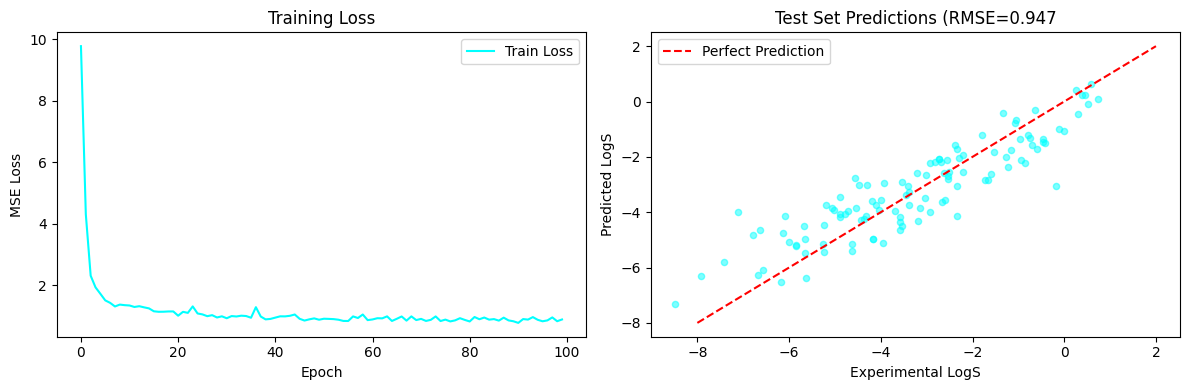

Plot saved to docs/gnn_results.png


In [7]:
# Load best model and test
model.load_state_dict(torch.load('../backend/app/models/solubility_gnn.pt'))
test_rmse, test_preds, test_targets = evaluate(test_loader)
print(f"Test RMSE: {test_rmse:.4f} log(mol/L)")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color='cyan', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

axes[1]. scatter(test_targets, test_preds, alpha=0.5, color='cyan', s=20)
axes[1].plot([-8, 2], [-8, 2], 'r--', label='Perfect Prediction')
axes[1].set_xlabel('Experimental LogS')
axes[1].set_ylabel('Predicted LogS')
axes[1].set_title(f'Test Set Predictions (RMSE={test_rmse:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/gnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to docs/gnn_results.png")

In [8]:
import json

metadata = {
    "model": "SolubilityGNN",
    "task": "Aqueous solubility prediction (LogS)",
    "dataset": "ESOL (Delaney)",
    "n_tain": len(train_data),
    "n_valid": len(valid_data),
    "n_test": len(test_data),
    "in_channels": int(in_channels),
    "hidden_channels": 64,
    "test_rmse": round(float(test_rmse), 4),
    "units": "log(mol/L)",
    "notes": "Lower LogS = less soluble. Drug-like range: -6 to 0"
}

with open('../backend/app/models/solubility_gnn_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved:")
print(json.dumps(metadata, indent=2))

Metadata saved:
{
  "model": "SolubilityGNN",
  "task": "Aqueous solubility prediction (LogS)",
  "dataset": "ESOL (Delaney)",
  "n_tain": 901,
  "n_valid": 113,
  "n_test": 113,
  "in_channels": 7,
  "hidden_channels": 64,
  "test_rmse": 0.9469,
  "units": "log(mol/L)",
  "notes": "Lower LogS = less soluble. Drug-like range: -6 to 0"
}
